In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/cleaned/retail_sales_cleaned.csv"
)

print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/cleaned/retail_sales_cleaned.csv'

In [4]:
import os

print(os.listdir("../data"))

FileNotFoundError: [Errno 2] No such file or directory: '../data'

In [5]:
import os

print(os.getcwd())

/Users/dhairyaamehta/Retail-Sales-Analytics


In [6]:
import os

print(os.listdir("data"))

['cleaned', 'raw']


In [7]:
print(os.listdir("data/raw"))

['Global_Superstore2.csv']


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/raw/Global_Superstore2.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month

print(df.shape)

(51290, 26)


In [9]:
monthly_sales = (
    df.groupby(["Order_Year", "Order_Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order_Year,Order_Month,Sales
0,2011,1,98898.48886
1,2011,2,91152.15698
2,2011,3,145729.36736
3,2011,4,116915.76418
4,2011,5,146747.83610


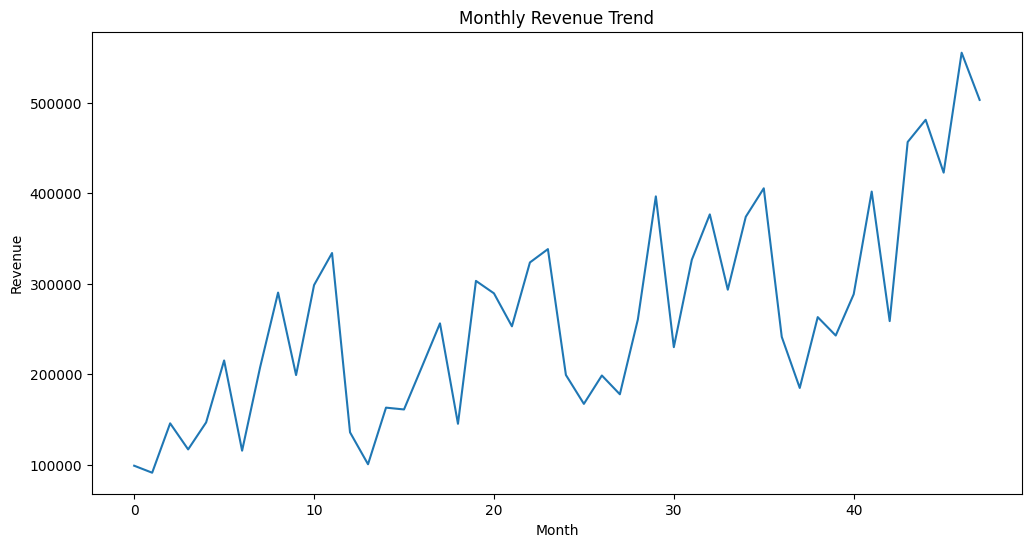

In [10]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales["Sales"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

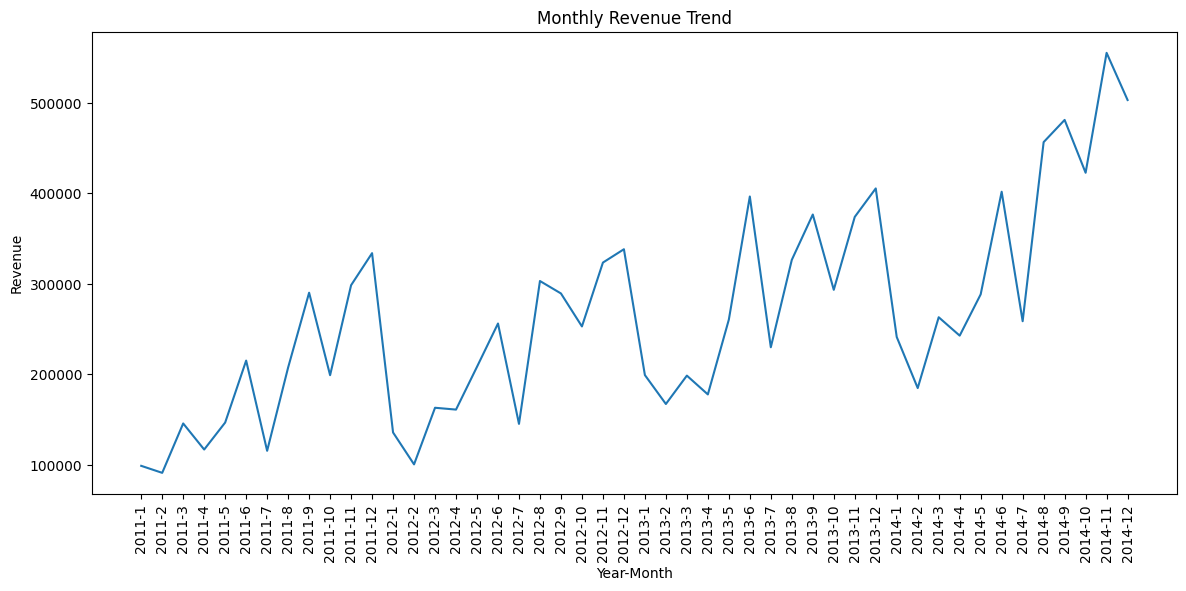

In [11]:
monthly_sales["YearMonth"] = (
    monthly_sales["Order_Year"].astype(str)
    + "-"
    + monthly_sales["Order_Month"].astype(str)
)

plt.figure(figsize=(14,6))

plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

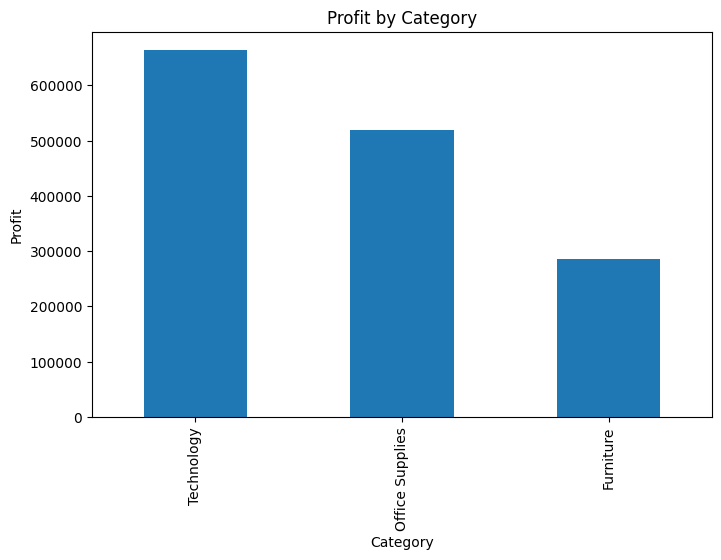

In [12]:
profit_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

profit_category.plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.show()

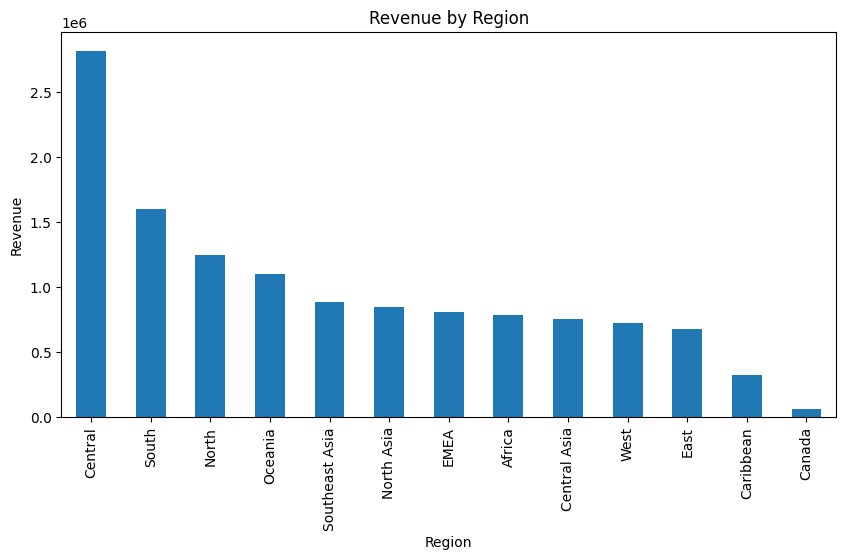

In [13]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.ylabel("Revenue")

plt.show()

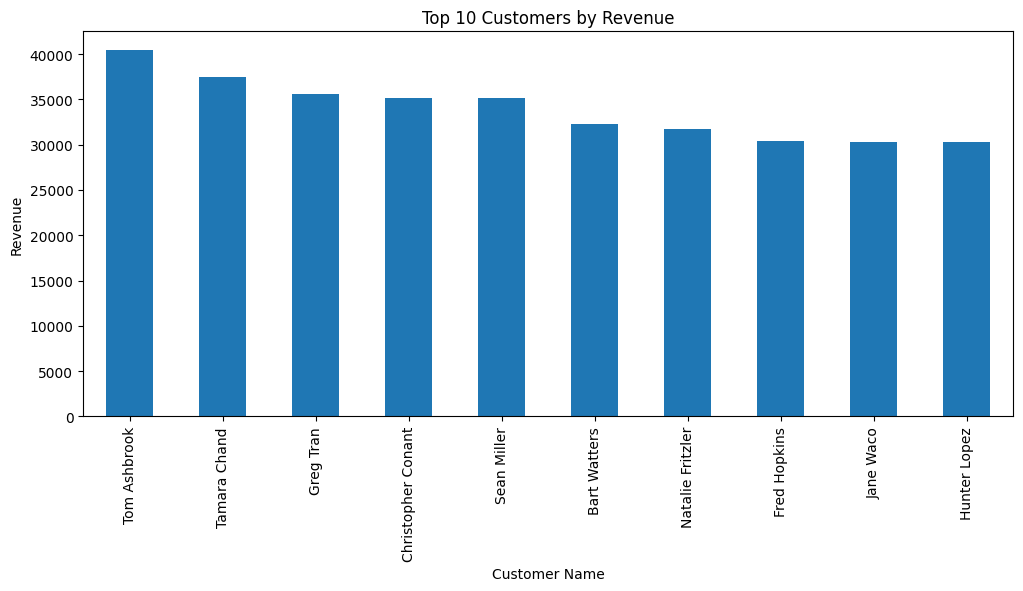

In [14]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.show()